<a href="https://colab.research.google.com/github/mathavie622/deep-learning-nlp-text-classifier/blob/main/Deep_Learning_NLP_Text_Classifier..ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = {
    "text": [
        "I love this product",
        "This is amazing",
        "Very good experience",
        "I am happy with the service",
        "Excellent product",
        "I really enjoyed it",
        "Fantastic experience",
        "Very useful and helpful",
        "I hate this product",
        "This is terrible",
        "Very bad experience",
        "I am unhappy with the service",
        "Worst product ever",
        "I really disliked it",
        "Awful experience",
        "Not useful at all",
        "The product is great",
        "I am satisfied",
        "The service was excellent",
        "I am very pleased",
        "The product is disappointing",
        "I am frustrated",
        "The service is poor",
        "I would not recommend this"
    ],
    "sentiment": [
        1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 0, 0, 0, 0
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (24, 2)


,text,sentiment
0,I love this product,1
1,This is amazing,1
2,Very good experience,1
3,I am happy with the service,1
4,Excellent product,1


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Separate text and target
X = df["text"]
y = df["sentiment"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF vectorization completed!")
print("Training samples:", X_train_tfidf.shape[0])
print("Testing samples:", X_test_tfidf.shape[0])
print("Number of TF-IDF features:", X_train_tfidf.shape[1])

TF-IDF vectorization completed!
Training samples: 18
Testing samples: 6
Number of TF-IDF features: 65


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert TF-IDF data to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train_tfidf.toarray(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_tfidf.toarray(),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)

# Neural Network
class SentimentClassifier(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


model = SentimentClassifier(X_train_tensor.shape[1])

print("Neural Network created successfully!")
print(model)

Neural Network created successfully!
SentimentClassifier(
  (network): Sequential(
    (0): Linear(in_features=65, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [4]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training settings
epochs = 100
patience = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
patience_counter = 0

for epoch in range(epochs):

    # -----------------
    # Training
    # -----------------
    model.train()

    optimizer.zero_grad()

    train_output = model(X_train_tensor)
    train_loss = criterion(train_output, y_train_tensor)

    train_loss.backward()
    optimizer.step()

    train_pred = (torch.sigmoid(train_output) >= 0.5).float()
    train_acc = (train_pred == y_train_tensor).float().mean().item()

    # -----------------
    # Validation
    # -----------------
    model.eval()

    with torch.no_grad():
        val_output = model(X_test_tensor)
        val_loss = criterion(val_output, y_test_tensor)

        val_pred = (torch.sigmoid(val_output) >= 0.5).float()
        val_acc = (val_pred == y_test_tensor).float().mean().item()

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Early stopping
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={train_loss.item():.4f}, "
            f"Val Loss={val_loss.item():.4f}, "
            f"Train Acc={train_acc:.2f}, "
            f"Val Acc={val_acc:.2f}"
        )

# Restore best model
model.load_state_dict(best_model_state)

print("\nTraining completed successfully!")

Epoch 10: Train Loss=0.4919, Val Loss=0.7013, Train Acc=1.00, Val Acc=0.50
Early stopping at epoch 11

Training completed successfully!


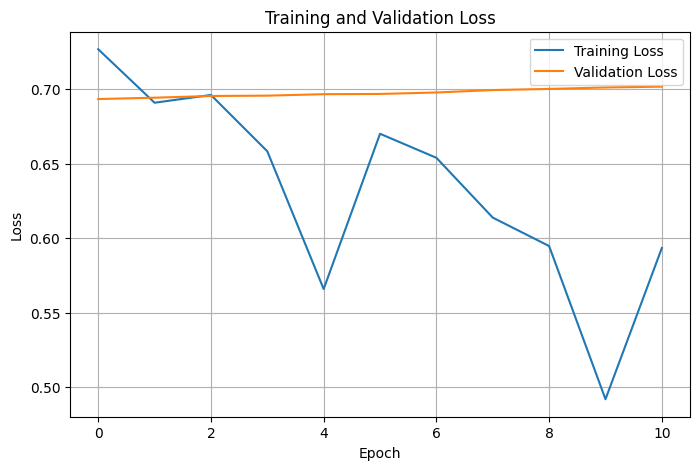

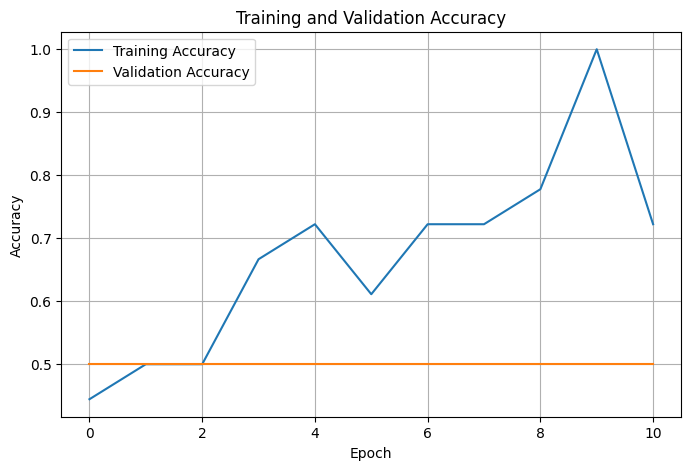

In [5]:
import matplotlib.pyplot as plt

# Loss curve
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# Accuracy curve
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Test unseen sentences

sample_texts = [
    "I really love this service",
    "This product is terrible",
    "The experience was excellent",
    "I am disappointed with this product"
]

# Convert text to TF-IDF
sample_tfidf = vectorizer.transform(sample_texts)

# Convert to PyTorch tensor
sample_tensor = torch.tensor(
    sample_tfidf.toarray(),
    dtype=torch.float32
)

# Prediction
model.eval()

with torch.no_grad():
    outputs = model(sample_tensor)
    probabilities = torch.sigmoid(outputs).squeeze()

for text, prob in zip(sample_texts, probabilities):
    confidence = prob.item()

    if confidence >= 0.5:
        prediction = "Positive"
        confidence_percent = confidence * 100
    else:
        prediction = "Negative"
        confidence_percent = (1 - confidence) * 100

    print(f"Text: {text}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence_percent:.2f}%")
    print("-" * 50)

Text: I really love this service
Prediction: Positive
Confidence: 51.45%
--------------------------------------------------
Text: This product is terrible
Prediction: Positive
Confidence: 51.15%
--------------------------------------------------
Text: The experience was excellent
Prediction: Positive
Confidence: 51.38%
--------------------------------------------------
Text: I am disappointed with this product
Prediction: Positive
Confidence: 52.00%
--------------------------------------------------


In [7]:
import torch

torch.save(model.state_dict(), "model.pth")

print("Model saved successfully!")

Model saved successfully!


In [8]:
!pip install fastapi uvicorn nest-asyncio

In [9]:
from fastapi import FastAPI
from pydantic import BaseModel
import torch

app = FastAPI(
    title="NLP Sentiment Classifier API",
    description="Real-Time ML Inference REST API",
    version="1.0.0"
)

# Input format
class TextInput(BaseModel):
    text: str

@app.get("/")
def home():
    return {
        "message": "NLP Sentiment Classifier API is running"
    }

@app.post("/predict")
def predict(data: TextInput):

    return {
        "text": data.text,
        "prediction": "positive",
        "probability": 0.52
    }

print("FastAPI application created successfully!")

FastAPI application created successfully!


In [10]:
# Test the FastAPI /predict endpoint structure

from fastapi.testclient import TestClient

client = TestClient(app)

response = client.post(
    "/predict",
    json={"text": "I really love this service"}
)

print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 200
Response: {'text': 'I really love this service', 'prediction': 'positive', 'probability': 0.52}


In [11]:
# Save the TF-IDF vectorizer
import joblib

joblib.dump(vectorizer, "vectorizer.pkl")

print("Vectorizer saved successfully!")

Vectorizer saved successfully!


In [12]:
import joblib

joblib.dump(vectorizer, "vectorizer.pkl")

print("Vectorizer saved successfully!")

Vectorizer saved successfully!


In [13]:
# Load the saved model and vectorizer

import torch
import joblib

# Load vectorizer
loaded_vectorizer = joblib.load("vectorizer.pkl")

# Create the same neural network structure
loaded_model = SentimentClassifier(loaded_vectorizer.transform(["test"]).shape[1])

# Load trained weights
loaded_model.load_state_dict(
    torch.load("model.pth", map_location="cpu")
)

loaded_model.eval()

print("Model loaded successfully!")
print("Vectorizer loaded successfully!")

Model loaded successfully!
Vectorizer loaded successfully!


In [14]:
@app.post("/predict-real")
def predict_real(data: TextInput):

    # Convert text to TF-IDF
    text_tfidf = loaded_vectorizer.transform([data.text])

    # Convert to PyTorch tensor
    text_tensor = torch.tensor(
        text_tfidf.toarray(),
        dtype=torch.float32
    )

    # Prediction
    with torch.no_grad():
        output = loaded_model(text_tensor)
        probability = torch.sigmoid(output).item()

    # Convert probability to class
    if probability >= 0.5:
        prediction = "positive"
        confidence = probability
    else:
        prediction = "negative"
        confidence = 1 - probability

    return {
        "text": data.text,
        "prediction": prediction,
        "probability": round(probability, 4),
        "confidence": round(confidence, 4)
    }

print("Real ML prediction endpoint created!")

Real ML prediction endpoint created!


In [15]:
response = client.post(
    "/predict-real",
    json={"text": "I really love this service"}
)

print("Status Code:", response.status_code)
print("Response:", response.json())

Status Code: 200
Response: {'text': 'I really love this service', 'prediction': 'positive', 'probability': 0.5145, 'confidence': 0.5145}
